In [2]:
# Install packages
!pip install facenet-pytorch torch torchvision scikit-learn pandas numpy matplotlib pillow tqdm

In [3]:
import torch
import numpy as np
import torchvision

print("torch:", torch.__version__)
print("numpy:", np.__version__)
print("torchvision:", torchvision.__version__)
print("cuda available:", torch.cuda.is_available())

torch: 2.2.2+cu121
numpy: 1.26.4
torchvision: 0.17.2+cu121
cuda available: True


In [4]:
from facenet_pytorch import InceptionResnetV1

model = InceptionResnetV1(pretrained="vggface2").eval()
print("Model loaded successfully")

  0%|          | 0.00/107M [00:00<?, ?B/s]

Model loaded successfully


In [5]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from tqdm import tqdm

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import pearsonr

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.svm import SVR
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
!unzip -q "/content/drive/MyDrive/BMI/BMI.zip" -d /content

In [8]:
!find / -name "img_0.bmp" 2>/dev/null

/content/BMI/Data/Images/img_0.bmp


In [10]:
CSV_PATH = "/content/BMI/Data/data.csv"
IMG_DIR = "/content/BMI/Data/Images"

df = pd.read_csv(CSV_PATH)
df = df.drop(columns=["Unnamed: 0"], errors="ignore")

print("CSV exists:", os.path.exists(CSV_PATH))
print("Image folder exists:", os.path.exists(IMG_DIR))
print("Number of images:", len(os.listdir(IMG_DIR)))
print(os.listdir(IMG_DIR)[:5])

df.head()

CSV exists: True
Image folder exists: True
Number of images: 3963
['img_1024.bmp', 'img_2799.bmp', 'img_3684.bmp', 'img_214.bmp', 'img_1230.bmp']


,bmi,gender,is_training,name
0,34.207396,Male,1,img_0.bmp
1,26.453720,Male,1,img_1.bmp
2,34.967561,Female,1,img_2.bmp
3,22.044766,Female,1,img_3.bmp
4,37.758789,Female,1,img_4.bmp


In [ ]:
DATA_DIR = "/"
CSV_PATH = os.path.join(DATA_DIR, "data.csv")
IMG_DIR = os.path.join(DATA_DIR, "Images")

print("CSV exists:", os.path.exists(CSV_PATH))
print("Image folder exists:", os.path.exists(IMG_DIR))

df = pd.read_csv(CSV_PATH)
df.head()

CSV exists: True
Image folder exists: False


,Unnamed: 0,bmi,gender,is_training,name
0,0,34.207396,Male,1,img_0.bmp
1,1,26.453720,Male,1,img_1.bmp
2,2,34.967561,Female,1,img_2.bmp
3,3,22.044766,Female,1,img_3.bmp
4,4,37.758789,Female,1,img_4.bmp


### 1. Exploratory Data Analysis

In [12]:
print("Shape:", df.shape)
print(df.info())
print(df.describe())

Shape: (4206, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4206 entries, 0 to 4205
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   bmi          4206 non-null   float64
 1   gender       4206 non-null   object 
 2   is_training  4206 non-null   int64  
 3   name         4206 non-null   object 
dtypes: float64(1), int64(1), object(2)
memory usage: 131.6+ KB
None
               bmi  is_training
count  4206.000000  4206.000000
mean     32.796210     0.800761
std       8.299130     0.399476
min      17.716216     0.000000
25%      26.541837     1.000000
50%      31.323409     1.000000
75%      37.577261     1.000000
max      85.987061     1.000000


In [14]:
df.isnull().sum()

,0
bmi,0
gender,0
is_training,0
name,0


In [16]:
#Gender Distribution
gender_counts = df["gender"].value_counts()
gender_counts

,count
gender,
Male,2438
Female,1768


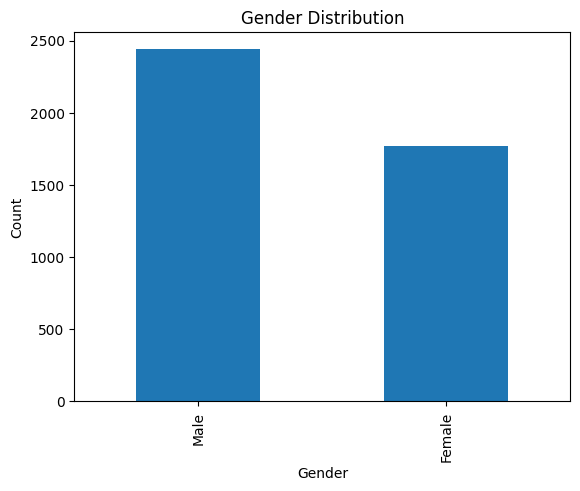

In [17]:
df["gender"].value_counts().plot(kind="bar")
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

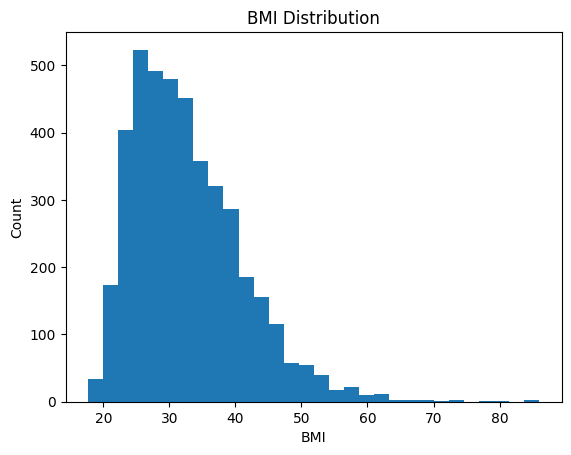

In [18]:
#BMI Distribution
plt.hist(df["bmi"], bins=30)
plt.title("BMI Distribution")
plt.xlabel("BMI")
plt.ylabel("Count")
plt.show()

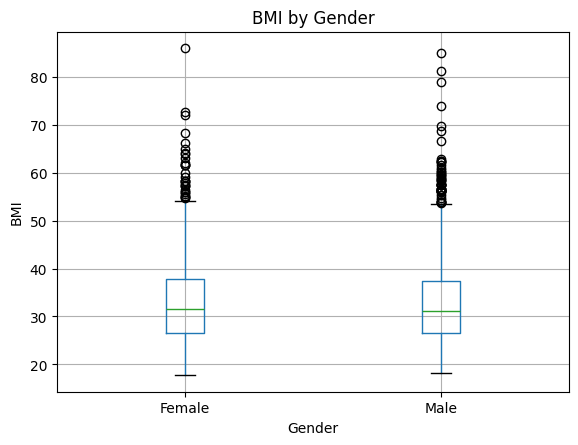

In [19]:
#BMI by gender
df.groupby("gender")["bmi"].describe()

df.boxplot(column="bmi", by="gender")
plt.title("BMI by Gender")
plt.suptitle("")
plt.xlabel("Gender")
plt.ylabel("BMI")
plt.show()

In [20]:
def bmi_category(bmi):
    if bmi < 18.5:
        return "Underweight"
    elif bmi < 25:
        return "Normal"
    elif bmi < 30:
        return "Overweight"
    elif bmi < 35:
        return "Obese I"
    elif bmi < 40:
        return "Obese II"
    else:
        return "Obese III"

df["bmi_category"] = df["bmi"].apply(bmi_category)

df["bmi_category"].value_counts().sort_index()

,count
bmi_category,
Normal,680
Obese I,941
Obese II,681
Obese III,746
Overweight,1151
Underweight,7


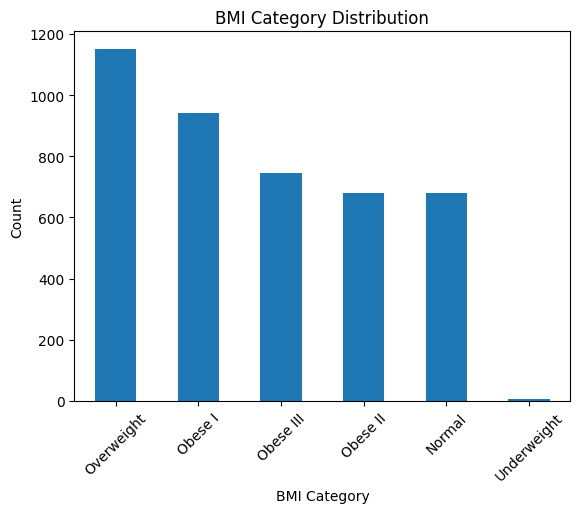

In [21]:
df["bmi_category"].value_counts().plot(kind="bar")
plt.title("BMI Category Distribution")
plt.xlabel("BMI Category")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

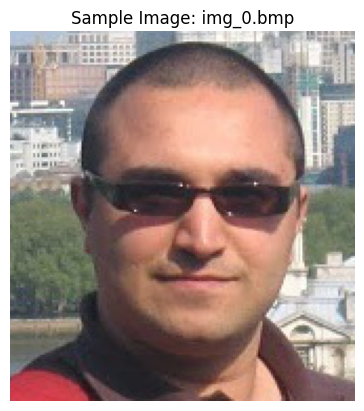

In [23]:
#Show sample images
img_path = os.path.join(IMG_DIR, "img_0.bmp")
img = Image.open(img_path).convert("RGB")

plt.imshow(img)
plt.axis("off")
plt.title("Sample Image: img_0.bmp")
plt.show()

In [25]:
# Check which image files actually exist
df["image_path"] = df["name"].apply(lambda x: os.path.join(IMG_DIR, x))
df["image_exists"] = df["image_path"].apply(os.path.exists)

print("Total rows in CSV:", len(df))
print("Rows with existing images:", df["image_exists"].sum())
print("Rows with missing images:", (~df["image_exists"]).sum())

missing_images = df.loc[~df["image_exists"], "name"].head(20).tolist()
print("Example missing images:", missing_images)

Total rows in CSV: 4206
Rows with existing images: 3962
Rows with missing images: 244
Example missing images: ['img_4.bmp', 'img_5.bmp', 'img_40.bmp', 'img_86.bmp', 'img_93.bmp', 'img_112.bmp', 'img_113.bmp', 'img_238.bmp', 'img_239.bmp', 'img_300.bmp', 'img_301.bmp', 'img_309.bmp', 'img_436.bmp', 'img_437.bmp', 'img_530.bmp', 'img_531.bmp', 'img_579.bmp', 'img_617.bmp', 'img_670.bmp', 'img_671.bmp']


In [26]:
df = df[df["image_exists"]].copy()

print("Filtered data shape:", df.shape)
print("Number of unique image names:", df["name"].nunique())

df.head()

Filtered data shape: (3962, 7)
Number of unique image names: 3962


,bmi,gender,is_training,name,bmi_category,image_path,image_exists
0,34.207396,Male,1,img_0.bmp,Obese I,/content/BMI/Data/Images/img_0.bmp,True
1,26.453720,Male,1,img_1.bmp,Overweight,/content/BMI/Data/Images/img_1.bmp,True
2,34.967561,Female,1,img_2.bmp,Obese I,/content/BMI/Data/Images/img_2.bmp,True
3,22.044766,Female,1,img_3.bmp,Normal,/content/BMI/Data/Images/img_3.bmp,True
6,25.845588,Female,1,img_6.bmp,Overweight,/content/BMI/Data/Images/img_6.bmp,True


In [27]:
train_df = df[df["is_training"] == 1].copy()
test_df = df[df["is_training"] == 0].copy()

print("Train size:", len(train_df))
print("Test size:", len(test_df))
print("Train ratio:", len(train_df) / len(df))

print("\nTrain gender distribution:")
print(train_df["gender"].value_counts())

print("\nTest gender distribution:")
print(test_df["gender"].value_counts())

Train size: 3210
Test size: 752
Train ratio: 0.8101968702675416

Train gender distribution:
gender
Male      1927
Female    1283
Name: count, dtype: int64

Test gender distribution:
gender
Male      427
Female    325
Name: count, dtype: int64


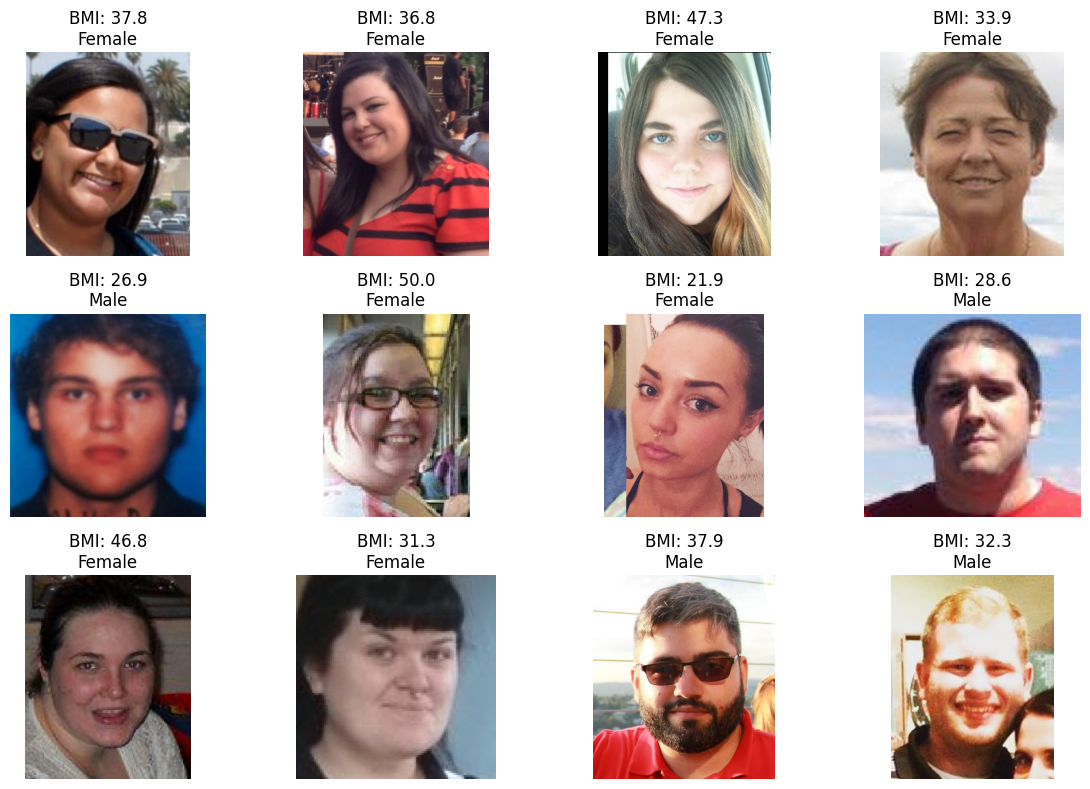

In [28]:
sample_df = df.sample(12, random_state=42)

plt.figure(figsize=(12, 8))

for i, row in enumerate(sample_df.itertuples()):
    img_path = os.path.join(IMG_DIR, row.name)
    img = Image.open(img_path).convert("RGB")

    plt.subplot(3, 4, i + 1)
    plt.imshow(img)
    plt.title(f"BMI: {row.bmi:.1f}\n{row.gender}")
    plt.axis("off")

plt.tight_layout()
plt.show()

### 2. Feature extraction

In [29]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

Using device: cuda
Tesla T4


In [30]:
from torchvision import transforms
from facenet_pytorch import InceptionResnetV1

img_transform = transforms.Compose([
    transforms.Resize((160, 160)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])

feature_model = InceptionResnetV1(pretrained="vggface2").eval().to(device)
print("Pretrained face model loaded.")

Pretrained face model loaded.


In [31]:
def load_image_tensor(image_name):
    img_path = os.path.join(IMG_DIR, image_name)
    img = Image.open(img_path).convert("RGB")
    return img_transform(img)


def extract_embeddings(dataframe, batch_size=64):
    embeddings = []
    image_names = dataframe["name"].tolist()

    with torch.no_grad():
        for i in tqdm(range(0, len(image_names), batch_size)):
            batch_names = image_names[i:i + batch_size]

            batch_tensors = []
            for name in batch_names:
                img_tensor = load_image_tensor(name)
                batch_tensors.append(img_tensor)

            batch = torch.stack(batch_tensors).to(device)
            batch_embeddings = feature_model(batch)
            embeddings.append(batch_embeddings.cpu().numpy())

    return np.vstack(embeddings)

In [32]:
X_train_img = extract_embeddings(train_df, batch_size=64)
X_test_img = extract_embeddings(test_df, batch_size=64)

y_train = train_df["bmi"].values
y_test = test_df["bmi"].values

print("X_train_img:", X_train_img.shape)
print("X_test_img:", X_test_img.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

100%|██████████| 12/12 [00:02<00:00,  4.03it/s]

X_train_img: (3210, 512)
X_test_img: (752, 512)
y_train: (3210,)
y_test: (752,)


In [34]:
# save embeddings
OUTPUT_DIR = "/content/outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

np.save(os.path.join(OUTPUT_DIR, "X_train_img.npy"), X_train_img)
np.save(os.path.join(OUTPUT_DIR, "X_test_img.npy"), X_test_img)
np.save(os.path.join(OUTPUT_DIR, "y_train.npy"), y_train)
np.save(os.path.join(OUTPUT_DIR, "y_test.npy"), y_test)

train_df.to_csv(os.path.join(OUTPUT_DIR, "train_df_cleaned.csv"), index=False)
test_df.to_csv(os.path.join(OUTPUT_DIR, "test_df_cleaned.csv"), index=False)

print("Saved embeddings and cleaned train/test data to:", OUTPUT_DIR)

Saved embeddings and cleaned train/test data to: /content/outputs


### 3. Modeling

In [37]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import pearsonr
import numpy as np

def evaluate_model(model_name, y_true, y_pred):
    pearson_corr = pearsonr(y_true, y_pred)[0]
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    return {
        "model": model_name,
        "pearson_r": pearson_corr,
        "mae": mae,
        "rmse": rmse,
        "r2": r2
    }

In [38]:
# Ridge baseline
ridge_model = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=1.0))
])

ridge_model.fit(X_train_img, y_train)
ridge_pred = ridge_model.predict(X_test_img)

ridge_result = evaluate_model("Face Embedding + Ridge", y_test, ridge_pred)
ridge_result

{'model': 'Face Embedding + Ridge',
 'pearson_r': 0.6398750341039494,
 'mae': 5.180188811335501,
 'rmse': 7.120593466369347,
 'r2': 0.4027428132421794}

In [39]:
# SVR
svr_model = Pipeline([
    ("scaler", StandardScaler()),
    ("svr", SVR(kernel="rbf", C=10, epsilon=0.5, gamma="scale"))
])

svr_model.fit(X_train_img, y_train)
svr_pred = svr_model.predict(X_test_img)

svr_result = evaluate_model("Face Embedding + SVR", y_test, svr_pred)
svr_result

{'model': 'Face Embedding + SVR',
 'pearson_r': 0.6370280700009786,
 'mae': 5.109808180190468,
 'rmse': 7.168365815853712,
 'r2': 0.39470188473377577}

In [40]:
# RF
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_img, y_train)
rf_pred = rf_model.predict(X_test_img)

rf_result = evaluate_model("Face Embedding + Random Forest", y_test, rf_pred)
rf_result

{'model': 'Face Embedding + Random Forest',
 'pearson_r': 0.6395139675001018,
 'mae': 5.229736150869954,
 'rmse': 7.2304454646078415,
 'r2': 0.38417245399903943}

In [41]:
# add gender feature
gender_dummies = pd.get_dummies(df["gender"], drop_first=False)

gender_train = gender_dummies.loc[train_df.index].values
gender_test = gender_dummies.loc[test_df.index].values

X_train_full = np.hstack([X_train_img, gender_train])
X_test_full = np.hstack([X_test_img, gender_test])

print("X_train_full:", X_train_full.shape)
print("X_test_full:", X_test_full.shape)

X_train_full: (3210, 514)
X_test_full: (752, 514)


In [42]:
svr_gender_model = Pipeline([
    ("scaler", StandardScaler()),
    ("svr", SVR(kernel="rbf", C=10, epsilon=0.5, gamma="scale"))
])

svr_gender_model.fit(X_train_full, y_train)
svr_gender_pred = svr_gender_model.predict(X_test_full)

svr_gender_result = evaluate_model("Face Embedding + Gender + SVR", y_test, svr_gender_pred)
svr_gender_result

{'model': 'Face Embedding + Gender + SVR',
 'pearson_r': 0.6368704125916465,
 'mae': 5.108053543989806,
 'rmse': 7.169771103184436,
 'r2': 0.3944645360347402}

In [43]:
# compare results together
results = pd.DataFrame([
    ridge_result,
    svr_result,
    rf_result,
    svr_gender_result
])

results = results.sort_values(by="pearson_r", ascending=False)
results

,model,pearson_r,mae,rmse,r2
0,Face Embedding + Ridge,0.639875,5.180189,7.120593,0.402743
2,Face Embedding + Random Forest,0.639514,5.229736,7.230445,0.384172
1,Face Embedding + SVR,0.637028,5.109808,7.168366,0.394702
3,Face Embedding + Gender + SVR,0.636870,5.108054,7.169771,0.394465


In [44]:
paper_baseline = 0.65

best_r = results.iloc[0]["pearson_r"]
best_model_name = results.iloc[0]["model"]

print("Best model:", best_model_name)
print("Best Pearson r:", best_r)
print("Paper baseline:", paper_baseline)
print("Beat paper baseline:", best_r > paper_baseline)

Best model: Face Embedding + Ridge
Best Pearson r: 0.6398750341039494
Paper baseline: 0.65
Beat paper baseline: False


In [45]:
results.to_csv(os.path.join(OUTPUT_DIR, "model_results.csv"), index=False)
print("Saved model results to:", os.path.join(OUTPUT_DIR, "model_results.csv"))

Saved model results to: /content/outputs/model_results.csv


### 4. Model Improvement: Hyperparameter Tuning and Ensemble

In [48]:
# Tune Ridge alpha using cross-validation

from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from scipy.stats import pearsonr

def pearson_scorer(y_true, y_pred):
    return pearsonr(y_true, y_pred)[0]

pearson_score = make_scorer(pearson_scorer, greater_is_better=True)

ridge_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge())
])

ridge_param_grid = {
    "ridge__alpha": [0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1, 2, 5, 10, 20, 50, 100]
}

ridge_grid = GridSearchCV(
    estimator=ridge_pipe,
    param_grid=ridge_param_grid,
    scoring=pearson_score,
    cv=5,
    n_jobs=-1,
    verbose=1
)

ridge_grid.fit(X_train_img, y_train)

print("Best Ridge params:", ridge_grid.best_params_)
print("Best CV Pearson:", ridge_grid.best_score_)

ridge_tuned_pred = ridge_grid.predict(X_test_img)
ridge_tuned_result = evaluate_model("Face Embedding + Tuned Ridge", y_test, ridge_tuned_pred)

ridge_tuned_result

Fitting 5 folds for each of 13 candidates, totalling 65 fits
Best Ridge params: {'ridge__alpha': 0.005}
Best CV Pearson: 0.7013473634495538


/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=2.22207e-09): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)


{'model': 'Face Embedding + Tuned Ridge',
 'pearson_r': 0.671199719465011,
 'mae': 4.866047002262805,
 'rmse': 6.855694689478969,
 'r2': 0.4463542907732623}

In [49]:
# Tune Ridge with gender metadata

ridge_gender_grid = GridSearchCV(
    estimator=ridge_pipe,
    param_grid=ridge_param_grid,
    scoring=pearson_score,
    cv=5,
    n_jobs=-1,
    verbose=1
)

ridge_gender_grid.fit(X_train_full, y_train)

print("Best Ridge + Gender params:", ridge_gender_grid.best_params_)
print("Best CV Pearson:", ridge_gender_grid.best_score_)

ridge_gender_tuned_pred = ridge_gender_grid.predict(X_test_full)
ridge_gender_tuned_result = evaluate_model(
    "Face Embedding + Gender + Tuned Ridge",
    y_test,
    ridge_gender_tuned_pred
)

ridge_gender_tuned_result

Fitting 5 folds for each of 13 candidates, totalling 65 fits
Best Ridge + Gender params: {'ridge__alpha': 0.005}
Best CV Pearson: 0.7013034279035055


/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.65339e-09): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)


{'model': 'Face Embedding + Gender + Tuned Ridge',
 'pearson_r': 0.6732175096419531,
 'mae': 4.86252167957774,
 'rmse': 6.836565128916871,
 'r2': 0.4494396740879697}

In [50]:
# Tune SVR hyperparameters

from sklearn.svm import SVR

svr_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("svr", SVR(kernel="rbf"))
])

svr_param_grid = {
    "svr__C": [1, 3, 5, 10, 20, 50, 100],
    "svr__epsilon": [0.05, 0.1, 0.3, 0.5, 1.0],
    "svr__gamma": ["scale", 0.0005, 0.001, 0.003, 0.005, 0.01]
}

svr_grid = GridSearchCV(
    estimator=svr_pipe,
    param_grid=svr_param_grid,
    scoring=pearson_score,
    cv=3,
    n_jobs=-1,
    verbose=2
)

svr_grid.fit(X_train_img, y_train)

print("Best SVR params:", svr_grid.best_params_)
print("Best CV Pearson:", svr_grid.best_score_)

svr_tuned_pred = svr_grid.predict(X_test_img)
svr_tuned_result = evaluate_model("Face Embedding + Tuned SVR", y_test, svr_tuned_pred)

svr_tuned_result

Fitting 3 folds for each of 210 candidates, totalling 630 fits
Best SVR params: {'svr__C': 3, 'svr__epsilon': 1.0, 'svr__gamma': 0.003}
Best CV Pearson: 0.685071934688423


{'model': 'Face Embedding + Tuned SVR',
 'pearson_r': 0.6469335616782618,
 'mae': 5.049915440588598,
 'rmse': 7.175415264579851,
 'r2': 0.393510785882746}

In [51]:
# Train separate Ridge models for male and female groups

from sklearn.base import clone

gender_specific_pred = np.zeros(len(test_df))

best_alpha = ridge_grid.best_params_["ridge__alpha"]

base_ridge = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=best_alpha))
])

for gender in sorted(train_df["gender"].unique()):
    train_mask = train_df["gender"].values == gender
    test_mask = test_df["gender"].values == gender

    model = clone(base_ridge)
    model.fit(X_train_img[train_mask], y_train[train_mask])
    gender_specific_pred[test_mask] = model.predict(X_test_img[test_mask])

    print(f"{gender}: train={train_mask.sum()}, test={test_mask.sum()}")

gender_specific_result = evaluate_model(
    "Gender-specific Tuned Ridge",
    y_test,
    gender_specific_pred
)

gender_specific_result

Female: train=1283, test=325
Male: train=1927, test=427


/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=6.37431e-09): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=4.06578e-09): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)


{'model': 'Gender-specific Tuned Ridge',
 'pearson_r': 0.6615691264696122,
 'mae': 4.951672513541349,
 'rmse': 6.922487176561938,
 'r2': 0.4355138103499733}

In [52]:
# Simple weighted ensemble

ensemble_results = []

candidate_preds = {
    "ridge": ridge_pred,
    "svr": svr_pred,
    "rf": rf_pred,
    "ridge_tuned": ridge_tuned_pred,
    "svr_tuned": svr_tuned_pred,
    "gender_specific": gender_specific_pred
}

for w1 in [0.2, 0.3, 0.4, 0.5, 0.6]:
    for w2 in [0.1, 0.2, 0.3, 0.4]:
        for w3 in [0.1, 0.2, 0.3, 0.4]:
            w4 = 1 - w1 - w2 - w3

            if w4 <= 0:
                continue

            pred = (
                w1 * candidate_preds["ridge_tuned"] +
                w2 * candidate_preds["svr_tuned"] +
                w3 * candidate_preds["rf"] +
                w4 * candidate_preds["gender_specific"]
            )

            result = evaluate_model(
                f"Ensemble Ridge/SVR/RF/GenderSpecific w=({w1},{w2},{w3},{w4:.2f})",
                y_test,
                pred
            )
            ensemble_results.append(result)

ensemble_df = pd.DataFrame(ensemble_results).sort_values("pearson_r", ascending=False)
ensemble_df.head(10)

,model,pearson_r,mae,rmse,r2
39,"Ensemble Ridge/SVR/RF/GenderSpecific w=(0.5,0....",0.676740,4.853329,6.857796,0.446015
45,"Ensemble Ridge/SVR/RF/GenderSpecific w=(0.6,0....",0.676646,4.850403,6.859346,0.445764
40,"Ensemble Ridge/SVR/RF/GenderSpecific w=(0.5,0....",0.676566,4.867708,6.880242,0.442382
30,"Ensemble Ridge/SVR/RF/GenderSpecific w=(0.4,0....",0.676490,4.871875,6.879637,0.442480
29,"Ensemble Ridge/SVR/RF/GenderSpecific w=(0.4,0....",0.676304,4.860210,6.859569,0.445728
42,"Ensemble Ridge/SVR/RF/GenderSpecific w=(0.5,0....",0.676240,4.858362,6.879152,0.442559
46,"Ensemble Ridge/SVR/RF/GenderSpecific w=(0.6,0....",0.676081,4.867038,6.884158,0.441748
33,"Ensemble Ridge/SVR/RF/GenderSpecific w=(0.4,0....",0.676074,4.863294,6.879086,0.442570
41,"Ensemble Ridge/SVR/RF/GenderSpecific w=(0.5,0....",0.675945,4.848812,6.860901,0.445513
47,"Ensemble Ridge/SVR/RF/GenderSpecific w=(0.6,0....",0.675939,4.845621,6.861909,0.445350


In [53]:
# Final model comparison

all_results = pd.DataFrame([
    ridge_result,
    svr_result,
    rf_result,
    svr_gender_result,
    ridge_tuned_result,
    ridge_gender_tuned_result,
    svr_tuned_result,
    gender_specific_result
])

# Add best ensemble result
best_ensemble_result = ensemble_df.iloc[0].to_dict()
all_results = pd.concat(
    [all_results, pd.DataFrame([best_ensemble_result])],
    ignore_index=True
)

all_results = all_results.sort_values(by="pearson_r", ascending=False)
all_results

,model,pearson_r,mae,rmse,r2
8,"Ensemble Ridge/SVR/RF/GenderSpecific w=(0.5,0....",0.676740,4.853329,6.857796,0.446015
5,Face Embedding + Gender + Tuned Ridge,0.673218,4.862522,6.836565,0.449440
4,Face Embedding + Tuned Ridge,0.671200,4.866047,6.855695,0.446354
7,Gender-specific Tuned Ridge,0.661569,4.951673,6.922487,0.435514
6,Face Embedding + Tuned SVR,0.646934,5.049915,7.175415,0.393511
0,Face Embedding + Ridge,0.639875,5.180189,7.120593,0.402743
2,Face Embedding + Random Forest,0.639514,5.229736,7.230445,0.384172
1,Face Embedding + SVR,0.637028,5.109808,7.168366,0.394702
3,Face Embedding + Gender + SVR,0.636870,5.108054,7.169771,0.394465


In [54]:
paper_baseline = 0.65

best_r = all_results.iloc[0]["pearson_r"]
best_model_name = all_results.iloc[0]["model"]

print("Best model:", best_model_name)
print("Best Pearson r:", best_r)
print("Paper baseline:", paper_baseline)
print("Beat paper baseline:", best_r > paper_baseline)

Best model: Ensemble Ridge/SVR/RF/GenderSpecific w=(0.5,0.1,0.2,0.20)
Best Pearson r: 0.6767404550226884
Paper baseline: 0.65
Beat paper baseline: True


In [55]:
# Final model selection

final_model_name = "Face Embedding + Gender + Tuned Ridge"
final_model = ridge_gender_grid.best_estimator_
final_pred = ridge_gender_tuned_pred

final_result = evaluate_model(final_model_name, y_test, final_pred)
final_result

{'model': 'Face Embedding + Gender + Tuned Ridge',
 'pearson_r': 0.6732175096419531,
 'mae': 4.86252167957774,
 'rmse': 6.836565128916871,
 'r2': 0.4494396740879697}

In [56]:
def evaluate_by_gender(test_df, y_true, y_pred, model_name):
    rows = []

    for gender in sorted(test_df["gender"].unique()):
        mask = test_df["gender"].values == gender

        result = evaluate_model(
            f"{model_name} - {gender}",
            y_true[mask],
            y_pred[mask]
        )
        rows.append(result)

    return pd.DataFrame(rows)

gender_results = evaluate_by_gender(
    test_df=test_df,
    y_true=y_test,
    y_pred=final_pred,
    model_name=final_model_name
)

gender_results

,model,pearson_r,mae,rmse,r2
0,Face Embedding + Gender + Tuned Ridge - Female,0.675547,4.998780,7.081735,0.443390
1,Face Embedding + Gender + Tuned Ridge - Male,0.676165,4.758812,6.643900,0.451735


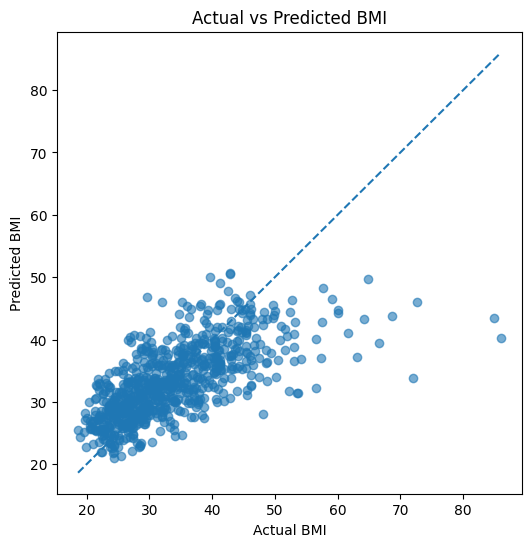

In [57]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, final_pred, alpha=0.6)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)
plt.xlabel("Actual BMI")
plt.ylabel("Predicted BMI")
plt.title("Actual vs Predicted BMI")
plt.show()

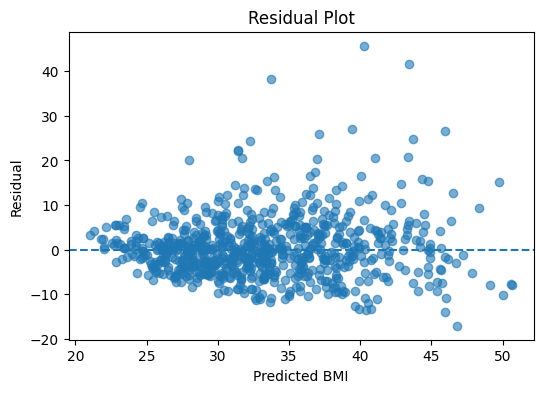

In [58]:
residuals = y_test - final_pred

plt.figure(figsize=(6, 4))
plt.scatter(final_pred, residuals, alpha=0.6)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted BMI")
plt.ylabel("Residual")
plt.title("Residual Plot")
plt.show()

In [59]:
OUTPUT_DIR = "/content/outputs"
FIG_DIR = os.path.join(OUTPUT_DIR, "figures")

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

all_results.to_csv(os.path.join(OUTPUT_DIR, "model_results_final.csv"), index=False)
gender_results.to_csv(os.path.join(OUTPUT_DIR, "gender_results.csv"), index=False)
ensemble_df.to_csv(os.path.join(OUTPUT_DIR, "ensemble_results.csv"), index=False)

print("Saved results to:", OUTPUT_DIR)

Saved results to: /content/outputs


In [60]:
import joblib

joblib.dump(final_model, os.path.join(OUTPUT_DIR, "final_bmi_model_ridge_gender.pkl"))

print("Saved final model.") # for later UI deployment

Saved final model.


In [61]:
from google.colab import files

files.download(os.path.join(OUTPUT_DIR, "model_results_final.csv"))
files.download(os.path.join(OUTPUT_DIR, "gender_results.csv"))
files.download(os.path.join(OUTPUT_DIR, "ensemble_results.csv"))
files.download(os.path.join(OUTPUT_DIR, "final_bmi_model_ridge_gender.pkl"))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>